# SCRFD with SPOS

This notebook implements the second stage of SPOS for neuron architecture search (NAS) task on face detection, it follows the strategies of SCRFD which are:
- Sample redistribution of hard data samples
- Flop constraning (in my case <= 2.5 GFlop)

To confirm the results claimed in SCRFD research paper of how computational power should be distributed on the network for the task of Face Detection, especially small and dense face detection.

## Paper: 
Single Path One-Shot Neural Architecture Search with Uniform Sampling (SPOS): https://arxiv.org/abs/1904.00420

Sample and Computation Redistribution for Efficient Face Detection (SCRFD): https://arxiv.org/abs/2105.04714

## Notebooks:
- Traning stage (first stage): https://www.kaggle.com/code/meowluvmatcha/2-5-gflop-setting-spos-supernet-for-scrfd

# Defining the search space

## Limit the space
- Chanels limit: According SCRFD paper, we know in advance that the most of computational power should be allocated for the C2 and C3 layer, so I let the first 2 layers have the larger search range than the 2 later layers.

- Part limit: Follow the SCRFD paper, we fix the settings of head and neck, only perform the search on the backbone configuration

## Architecture choices

I follow the architecture of MobileNetv2, replacing the conv block with the InvertedResidual block. 

In [1]:
import os
# Chống phân mảnh VRAM (Lỗ hổng thủng lưới GPU)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import cv2
# Khóa đa luồng ngầm của OpenCV (Nguyên nhân hàng đầu gây tràn RAM hệ thống)
cv2.setNumThreads(0) 

import torch
import gc
import time
import math
import random
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np

# Tắt Benchmark của CuDNN để tránh nó sinh Cache vô hạn cho 400 kiến trúc
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [2]:
import torch
import torch.nn as nn
import random

# 2d search space
SEARCH_SPACE = {
    'C2_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)], 
    'C3_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)],   
    'C4_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)],    
    'C5_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)]      
}


print("Đã load cấu hình Search Space!")

Đã load cấu hình Search Space!


# Dynamic resize blocks

In the previous implementation, at each stages, we swap in and out blocks with different sizes and for those block to be able to fit together we used padding for the output channels. Because the input channels were fixed at the maximum possible size. When we want to pass data from layers to another, if the output of the current layer is smaller than 


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math

class DynamicConv2d(nn.Module):
    """Lớp Tích chập tự động cắt trọng số (Weight Slicing)"""
    def __init__(self, max_in_channels, max_out_channels, kernel_size=1, stride=1, padding=0, groups=1):
        super(DynamicConv2d, self).__init__()
        # Khởi tạo ma trận trọng số LỚN NHẤT
        self.weight = nn.Parameter(torch.Tensor(max_out_channels, max_in_channels // groups, kernel_size, kernel_size))
        self.bias = nn.Parameter(torch.Tensor(max_out_channels))
        
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        nn.init.zeros_(self.bias)

        self.stride = stride
        self.padding = padding
        self.groups = groups

    def forward(self, x, active_out_c):
        in_c = x.shape[1] # Tự động nhận diện số kênh thực tế của đầu vào
        out_c = active_out_c
        
        # Xử lý tự động cho Depthwise Convolution (groups > 1)
        active_groups = in_c if self.groups > 1 else 1

        # CẮT TRỌNG SỐ: Chỉ lấy 1 góc của ma trận trọng số (Phần lõi)
        active_weight = self.weight[:out_c, :in_c // active_groups, :, :]
        active_bias = self.bias[:out_c]

        return F.conv2d(x, active_weight, active_bias, self.stride, self.padding, groups=active_groups)
class DynamicBatchNorm2d(nn.Module):
    """Lớp Batch Norm Tối Ưu Tuyệt Đối cho NAS"""
    def __init__(self, max_channels):
        super(DynamicBatchNorm2d, self).__init__()
        self.bn = nn.BatchNorm2d(max_channels)

    def forward(self, x):
        c = x.shape[1] # Cắt đúng số kênh đang hoạt động
        weight = self.bn.weight[:c]
        bias = self.bn.bias[:c]

        if self.bn.training:
            # Trick C++: Truyền None, None. 
            # PyTorch sẽ tự đo mean/var của batch này và chuẩn hóa mà KHÔNG cấp phát hay lưu trữ rác.
            return F.batch_norm(x, None, None, weight, bias, True, 0.0, self.bn.eps)
        else:
            # Chế độ Eval nguyên thủy
            rm = self.bn.running_mean[:c] if self.bn.track_running_stats else None
            rv = self.bn.running_var[:c] if self.bn.track_running_stats else None
            return F.batch_norm(x, rm, rv, weight, bias, False, 0.0, self.bn.eps)

In [4]:
class DynamicInvertedResidual(nn.Module):
    """Block Inverted Residual dùng Weight Slicing"""
    def __init__(self, max_in_channels, max_out_channels, stride, expand_ratio=4):
        super(DynamicInvertedResidual, self).__init__()
        max_hidden_dim = int(max_in_channels * expand_ratio)

        # 1. Lớp Expand (1x1)
        self.conv1 = DynamicConv2d(max_in_channels, max_hidden_dim, kernel_size=1)
        self.bn1 = DynamicBatchNorm2d(max_hidden_dim)

        # 2. Lớp Depthwise (3x3)
        self.conv2 = DynamicConv2d(max_hidden_dim, max_hidden_dim, kernel_size=3, stride=stride, padding=1, groups=max_hidden_dim)
        self.bn2 = DynamicBatchNorm2d(max_hidden_dim)

        # 3. Lớp Project (1x1)
        self.conv3 = DynamicConv2d(max_hidden_dim, max_out_channels, kernel_size=1)
        self.bn3 = DynamicBatchNorm2d(max_out_channels)
        self.stride = stride

    def forward(self, x, active_out_channels):
        in_c = x.shape[1]
        active_hidden_dim = in_c * 4 # Tính toán số kênh ẩn tương ứng với kênh đầu vào

        out = self.conv1(x, active_hidden_dim)
        out = self.bn1(out)
        out = F.relu6(out, inplace=True)

        out = self.conv2(out, active_hidden_dim)
        out = self.bn2(out)
        out = F.relu6(out, inplace=True)

        out = self.conv3(out, active_out_channels)
        out = self.bn3(out)

        # Skip connection (Chỉ cộng khi cùng số kênh và stride = 1)
        if self.stride == 1 and in_c == active_out_channels:
            return x + out
        return out


In [5]:
class DynamicChoiceBlock(nn.Module):
    """Khối SPOS chuẩn: Xử lý cả Width Slicing và Depth Drop"""
    def __init__(self, max_in_channels, options_list, stride):
        super(DynamicChoiceBlock, self).__init__()
        self.options_list = options_list

        # Tìm năng lực TỐI ĐA (Max Capacity) để cấp phát RAM
        self.max_width = max([w for w, d in options_list])
        self.max_depth = max([d for w, d in options_list])

        self.blocks = nn.ModuleList()
        for i in range(self.max_depth):
            s = stride if i == 0 else 1
            # Block đầu tiên nhận max_in_channels từ tầng trước. 
            # Các block sau nhận max_width của chính khối này.
            inp = max_in_channels if i == 0 else self.max_width
            self.blocks.append(
                DynamicInvertedResidual(inp, self.max_width, stride=s, expand_ratio=4)
            )

    def forward(self, x):
        if self.training:
            # PHA 1 (Train): Bốc ngẫu nhiên 1 đường cấu hình
            active_width, active_depth = random.choice(self.options_list)
        else:
            # PHA 2 (Search): Đi theo cấu hình được chỉ định (mặc định lấy max nếu chưa set)
            active_width = getattr(self, 'active_width', self.max_width)
            active_depth = getattr(self, 'active_depth', self.max_depth)

        # SEARCH CHIỀU SÂU: Chỉ chạy qua số block bằng với active_depth
        for i in range(active_depth):
            # Block tự động cắt trọng số theo active_width
            x = self.blocks[i](x, active_width)

        return x

class SPOS_Backbone(nn.Module):
    """Supernet Backbone tối ưu, KHÔNG DÙNG PADDING"""
    def __init__(self, search_space):
        super(SPOS_Backbone, self).__init__()

        # Stem mặc định (Cần phải viết lại thành DynamicConv2d nếu bạn cũng muốn search Stem)
        # Ở đây giữ nguyên tĩnh theo code cũ của bạn
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU6(inplace=True)
        )

        def get_max_width(options):
            return max([width for width, depth in options])

        # Các tầng tự động liên kết với nhau bằng kích thước Tối Đa
        self.c2 = DynamicChoiceBlock(16, search_space['C2_channels'], stride=2)
        
        c2_max = get_max_width(search_space['C2_channels'])
        self.c3 = DynamicChoiceBlock(c2_max, search_space['C3_channels'], stride=2)
        
        c3_max = get_max_width(search_space['C3_channels'])
        self.c4 = DynamicChoiceBlock(c3_max, search_space['C4_channels'], stride=2)
        
        c4_max = get_max_width(search_space['C4_channels'])
        self.c5 = DynamicChoiceBlock(c4_max, search_space['C5_channels'], stride=2)

    def forward(self, x):
        c1 = self.stem(x)
        c2 = self.c2(c1)
        c3 = self.c3(c2)
        c4 = self.c4(c3)
        c5 = self.c5(c4)

        return [c2, c3, c4, c5]


In [6]:
import torch.nn.functional as F

class SharedPAFPN(nn.Module):
    """Khối Neck (PAFPN) dùng chung cho mọi Backbone"""
    def __init__(self, in_channels_list, out_channels=64):
        super(SharedPAFPN, self).__init__()
        self.in_channels_list = in_channels_list

        # 1. Lateral Layers (Chuyển đổi số kênh của C2, C3, C4, C5 về chung 1 chuẩn out_channels)
        self.lat_c2 = nn.Conv2d(in_channels_list[0], out_channels, 1)
        self.lat_c3 = nn.Conv2d(in_channels_list[1], out_channels, 1)
        self.lat_c4 = nn.Conv2d(in_channels_list[2], out_channels, 1)
        self.lat_c5 = nn.Conv2d(in_channels_list[3], out_channels, 1)

        # 2. Downsample Layers (Dùng cho nhánh Bottom-Up của PAFPN)
        self.down_p2 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)
        self.down_p3 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)
        self.down_p4 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)

    def _align_channels(self, x, expected_c):
        """Hàm đệm thêm số 0 nếu Backbone xuất ra ít kênh hơn mức tối đa"""
        B, C, H, W = x.shape
        if C < expected_c:
            padding = torch.zeros(B, expected_c - C, H, W, device=x.device)
            x = torch.cat([x, padding], dim=1)
        return x

    def forward(self, features):
        c2, c3, c4, c5 = features

        # Đệm kênh cho chuẩn
        c2 = self._align_channels(c2, self.in_channels_list[0])
        c3 = self._align_channels(c3, self.in_channels_list[1])
        c4 = self._align_channels(c4, self.in_channels_list[2])
        c5 = self._align_channels(c5, self.in_channels_list[3])

        # Chuyển đổi về chung 1 số kênh (vd: 64)
        l2, l3, l4, l5 = self.lat_c2(c2), self.lat_c3(c3), self.lat_c4(c4), self.lat_c5(c5)

        # --- Nhánh Top-Down (FPN truyền thống) ---
        p5 = l5
        p4 = l4 + F.interpolate(p5, size=l4.shape[-2:], mode='nearest')
        p3 = l3 + F.interpolate(p4, size=l3.shape[-2:], mode='nearest')
        p2 = l2 + F.interpolate(p3, size=l2.shape[-2:], mode='nearest')

        # --- Nhánh Bottom-Up (PAFPN mở rộng) ---
        n2 = p2
        n3 = p3 + self.down_p2(n2)
        n4 = p4 + self.down_p3(n3)
        n5 = p5 + self.down_p4(n4)

        return [n2, n3, n4, n5]

class ProxyHeatmapHead(nn.Module):
    """Khối Head ủy quyền tối giản: Chỉ dự đoán 1 kênh Heatmap"""
    def __init__(self, in_channels=64, feature_channels=96):
        super(ProxyHeatmapHead, self).__init__()
        
        # Trích xuất đặc trưng có GroupNorm để ổn định NAS
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels, feature_channels, kernel_size=3, padding=1),
            nn.GroupNorm(32, feature_channels),
            nn.ReLU(inplace=True)
        )
        
        # XUẤT RA 1 KÊNH DUY NHẤT (Logits thô)
        self.heatmap_out = nn.Conv2d(feature_channels, 1, kernel_size=1)
        # =========================================================
        # FIX QUAN TRỌNG: Khởi tạo Prior Probability cho Focal Loss
        # =========================================================
        prior_prob = 0.01  # Bắt đầu với niềm tin "chỉ 1% pixel là mặt người"
        bias_value = -math.log((1.0 - prior_prob) / prior_prob)
        
        # Khởi tạo trọng số nhẹ nhàng và gán Bias để chống nổ Loss
        nn.init.normal_(self.heatmap_out.weight, std=0.01)
        nn.init.constant_(self.heatmap_out.bias, bias_value)

    
    def forward(self, pafpn_features):
        outputs = []
        for feat in pafpn_features[1:]: 
            x = self.feature_extractor(feat)
            out = self.heatmap_out(x)
            
            # TRẢ VỀ RAW LOGITS (Tuyệt đối không dùng torch.sigmoid ở đây)
            outputs.append(out) 
        return outputs

# Review of how we reduce the training time and inference time

Although we fixed the neck and the head, for face detection, SCRFD designed thier network similar to RetinaFace network, and this network use Focal Loss (and multi-loss function for bouding box regression). 

Knowing this, I conducted the followings reduction:
- Skipped the bounding box regression tasks (because this is not pure matrix multiplication so I assume it will slow :D )
- Backpropagation from the loss computed from the output heatmap: Object detection task will have an output heatmap before going to the box regression, with the training data available on wider face dataset, I preprocessed them into heatmap, and trained the supernet on those.
- And some vibing python optimization tricks Chat gpt told me.

*Note* I know that training on the heatmap only was not optimal, and can severly reduce the benckmark score of the final architecture. But for reproducing and validating the resulting architecture I think this is enough :< this is my course work anyway.  


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np

class WiderFaceHeatmapDataset(Dataset):
    def __init__(self, hf_dataset, img_size=(640, 640)):
        self.dataset = hf_dataset
        self.img_size = img_size
        self.strides = [8, 16, 32] # 4 mức scale của Supernet

    def __len__(self):
        return len(self.dataset)

    def _create_heatmap(self, target_size, bboxes, stride, orig_w, orig_h):
        """Hàm vẽ điểm tâm của khuôn mặt lên bản đồ nhiệt"""
        # Khởi tạo heatmap toàn số 0
        heatmap = torch.zeros((1, target_size[0], target_size[1]), dtype=torch.float32)

        # Tỷ lệ thu phóng ảnh gốc so với ảnh 640x640
        scale_x = self.img_size[1] / orig_w
        scale_y = self.img_size[0] / orig_h

        for bbox in bboxes:
            x_min, y_min, w, h = bbox
            # Bỏ qua các khuôn mặt quá nhỏ hoặc lỗi
            if w < 2 or h < 2: continue

            # Tính tọa độ tâm trên ảnh 640x640
            center_x = (x_min + w / 2) * scale_x
            center_y = (y_min + h / 2) * scale_y

            # Chiếu tọa độ tâm xuống kích thước lưới của Stride hiện tại
            grid_x = int(center_x / stride)
            grid_y = int(center_y / stride)

            # Đảm bảo tọa độ không bị vượt quá giới hạn (out of bounds)
            if 0 <= grid_x < target_size[1] and 0 <= grid_y < target_size[0]:
                # Gán nhãn 1 (Có mặt người)
                heatmap[0, grid_y, grid_x] = 1.0

                # Mẹo nhỏ: Đánh dấu các ô kế cận (Blur nhẹ) để mạng dễ hội tụ hơn
                # (Tạo một vùng 3x3 quanh tâm với giá trị 0.5)
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        nx, ny = grid_x + dx, grid_y + dy
                        if (dx != 0 or dy != 0) and 0 <= nx < target_size[1] and 0 <= ny < target_size[0]:
                            # Chỉ ghi đè nếu ô đó đang là 0 (để không xóa mất tâm 1.0)
                            if heatmap[0, ny, nx] == 0:
                                heatmap[0, ny, nx] = 0.5

        return heatmap

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        img_path = sample['image_path']

        # --- BẢN VÁ LỖI TRÀN RAM HỆ THỐNG ---
        # Mở file dưới dạng binary và ép đóng ngay sau khi thoát khỏi khối 'with'
        with open(img_path, 'rb') as f:
            with Image.open(f) as pil_img:
                img = pil_img.convert("RGB")
        # ------------------------------------

        orig_w, orig_h = img.size
        bboxes = sample['faces']['bbox']

        # Tiền xử lý ảnh (Resize và Normalize)
        img_resized = img.resize(self.img_size, Image.BILINEAR)
        img_tensor = TF.to_tensor(img_resized)

        # Tạo 4 Heatmaps cho 4 Strides
        heatmaps = []
        for stride in self.strides:
            grid_h, grid_w = self.img_size[0] // stride, self.img_size[1] // stride
            hm = self._create_heatmap((grid_h, grid_w), bboxes, stride, orig_w, orig_h)
            heatmaps.append(hm)

        # Xóa các biến tạm dọn đường cho Dataloader
        del img, img_resized, sample
        
        return img_tensor, heatmaps


In [8]:
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F


class ProxyFocalLossWithLogits(nn.Module):
    """
    Hàm Focal Loss rút gọn, NHẬN LOGITS THÔ ĐẦU VÀO để chống lỗi nan/inf khi dùng AMP.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(ProxyFocalLossWithLogits, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, pred_logits, targets):
        # pred_logits: Raw outputs chưa qua sigmoid
        # targets: Ground Truth heatmaps
        
        total_loss = 0.0

        for logits, target in zip(pred_logits, targets):
            # BƯỚC 1: BẮT BUỘC ÉP VỀ FP32 ĐỂ TÍNH TOÁN AN TOÀN TRONG AMP
            logits = logits.float()
            target = target.float()

            # BƯỚC 2: TÍNH BCE LOSS BẰNG HÀM C++ CỦA PYTORCH
            # Hàm này tối ưu log-sum-exp toán học, KHÔNG BAO GIỜ bị log(0)
            bce_loss = F.binary_cross_entropy_with_logits(logits, target, reduction='none')

            # BƯỚC 3: TÍNH FOCAL WEIGHT (TRỌNG SỐ PHẠT)
            # Lúc này tính sigmoid trên không gian FP32 là hoàn toàn an toàn
            pred_prob = torch.sigmoid(logits)

            pos_mask = (target > 0).float()
            neg_mask = (target == 0).float()

            # Trọng số cho điểm dương (Mặt người)
            pos_weight = (1.0 - pred_prob)**self.gamma * pos_mask * target
            
            # Trọng số cho điểm âm (Nền)
            neg_weight = pred_prob**self.gamma * neg_mask

            focal_weight = pos_weight + neg_weight

            # BƯỚC 4: KẾT HỢP LOSS VÀ WEIGHT
            num_pos = pos_mask.sum()
            loss_map = focal_weight * bce_loss
            num_pos = torch.clamp(num_pos, min=1.0)
            # Trung bình loss (chia cho số lượng đối tượng, tránh chia 0)
            total_loss += loss_map.sum() / num_pos

        return total_loss

# Khởi tạo hàm Loss
# criterion = ProxyFocalLossWithLogits()
# print("Đã khởi tạo hàm Proxy Focal Loss thành công!")

In [9]:
import os
import torch
import random
import math
from torch.utils.data import DataLoader
from torch.amp import autocast

# ==========================================
# 1. HÀM ĐỌC DỮ LIỆU KÈM CHIẾN LƯỢC TÁI PHÂN PHỐI (SR)
# ==========================================
def parse_wider_face_with_sr(gt_file_path, images_base_dir):
    """
    Đọc dữ liệu WIDER FACE và tính toán 'trọng số độ khó' (difficulty score) 
    cho từng bức ảnh để phục vụ việc lấy mẫu (Sample Redistribution).
    """
    dataset_info = []
    if not os.path.exists(gt_file_path):
        print(f"❌ Không tìm thấy file GT: {gt_file_path}")
        return dataset_info

    with open(gt_file_path, 'r') as f:
        lines = [line.strip() for line in f.readlines()]

    i = 0
    while i < len(lines):
        img_rel = lines[i]

        if not img_rel.endswith('.jpg'):
            i += 1
            continue

        try:
            num_faces = int(lines[i+1])
        except (ValueError, IndexError):
            i += 1
            continue

        bboxes = []
        avg_area = 0
        
        if num_faces == 0:
            step = 3
        else:
            total_area = 0
            valid_faces = 0
            for j in range(num_faces):
                if i + 2 + j < len(lines):
                    info = [int(x) for x in lines[i+2+j].split() if x]
                    if len(info) >= 4:
                        w, h = info[2], info[3]
                        # Loại bỏ các khuôn mặt quá bé (nhiễu) hoặc bị sai kích thước
                        if w > 0 and h > 0:
                            bboxes.append(info[:4])
                            total_area += (w * h)
                            valid_faces += 1
                            
            step = 2 + num_faces
            if valid_faces > 0:
                avg_area = total_area / valid_faces

        img_full_path = os.path.join(images_base_dir, img_rel)
        
        # --- CHIẾN LƯỢC SAMPLE REDISTRIBUTION (SR) ---
        # Tính điểm độ khó: Ưu tiên ảnh NHIỀU MẶT (Dense) và MẶT NHỎ (Small area)
        # Sử dụng log/sqrt để làm dịu các giá trị quá cực đoan.
        if os.path.exists(img_full_path) and len(bboxes) > 0:
            # Điểm mật độ: log(số lượng mặt + 1)
            dense_score = math.log1p(len(bboxes)) 
            
            # Điểm kích thước: Ảnh có trung bình diện tích mặt nhỏ sẽ được điểm cao
            # Thêm epsilon để tránh chia cho 0. Diện tích ảnh WIDER khoảng 1024x768.
            small_score = 1000.0 / (math.sqrt(avg_area) + 1.0) 
            
            # Trọng số cuối cùng (Bạn có thể điều chỉnh hệ số cân bằng nếu cần)
            difficulty_weight = dense_score * small_score
            
            dataset_info.append({
                'image_path': img_full_path, 
                'faces': {'bbox': bboxes},
                'weight': difficulty_weight
            })

        i += step

    return dataset_info

In [10]:
import os
import torch
from huggingface_hub import hf_hub_download
import torch.nn as nn # Bổ sung thư viện này nếu chưa có

# ==========================================
# 1. KHÔI PHỤC MẠNG SUPERNET
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_file = '/kaggle/input/models/meowluvmatcha/scrfd-spos-dynamic-increase-searchspace/pytorch/default/1/supernet_epoch2d_dynamic_increase_search_space.pth'
checkpoint = torch.load(checkpoint_file, map_location=device)
SEARCH_SPACE = checkpoint['search_space']
max_channels = checkpoint['max_channels']

supernet_backbone = SPOS_Backbone(SEARCH_SPACE).to(device)
neck = SharedPAFPN(in_channels_list=max_channels, out_channels=32).to(device)
head = ProxyHeatmapHead(in_channels=32).to(device)

# BƯỚC A: Load trọng số VÀO MÔ HÌNH GỐC trước
supernet_backbone.load_state_dict(checkpoint['supernet_backbone_state_dict'])
neck.load_state_dict(checkpoint['neck_state_dict'])
head.load_state_dict(checkpoint['head_state_dict'])

# BƯỚC B: BỌC MÔ HÌNH BẰNG DATAPARALLEL ĐỂ DÙNG NHIỀU GPU
# if torch.cuda.device_count() > 1:
#     print(f"🚀 Tuyệt vời! Phát hiện {torch.cuda.device_count()} GPUs. Đang kích hoạt chạy song song...")
#     supernet_backbone = nn.DataParallel(supernet_backbone)
#     neck = nn.DataParallel(neck)
#     head = nn.DataParallel(head)

supernet_backbone.eval()
neck.eval()
head.eval()
criterion = ProxyFocalLossWithLogits().to(device)
print("✅ Đã khôi phục Supernet và sẵn sàng chạy Multi-GPU!")
# ==========================================
# 2. KHỞI TẠO DATALOADER VỚI CÂY THƯ MỤC CỦA BẠN
# ==========================================
# Đường dẫn Train
train_gt_file = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_train_bbx_gt.txt"
train_images_dir = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_train/WIDER_train/images"

# Đường dẫn Val
val_gt_file = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_val_bbx_gt.txt"
val_images_dir = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images"

print("⏳ Đang phân tích Train Data...")
train_data_raw = parse_wider_face_with_sr(train_gt_file, train_images_dir)
print(f"✅ Đã tìm thấy {len(train_data_raw)} ảnh Train hợp lệ.")

print("⏳ Đang phân tích Val Data...")
val_data_raw = parse_wider_face_with_sr(val_gt_file, val_images_dir)
print(f"✅ Đã tìm thấy {len(val_data_raw)} ảnh Val hợp lệ.")

# Lấy mẫu theo tỷ lệ độ khó (SR Strategy)
random.seed(42)

# Tập Train để Recalibrate BN (khoảng 2000 ảnh là đủ, không cần chạy qua 20.000 ảnh nếu bạn muốn search nhanh)
train_weights = [item['weight'] for item in train_data_raw]
train_sr_subset = random.choices(train_data_raw, weights=train_weights, k=2000)

# Tập Val để chấm điểm mạng (chọn 640 ảnh khó nhất)
val_weights = [item['weight'] for item in val_data_raw]
val_sr_subset = random.choices(val_data_raw, weights=val_weights, k=640)

# [LƯU Ý]: Giả định bạn đã khai báo lớp WiderFaceHeatmapDataset
train_dataset = WiderFaceHeatmapDataset(train_sr_subset, img_size=(640, 640))
val_dataset = WiderFaceHeatmapDataset(val_sr_subset, img_size=(640, 640))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
print("🚀 Dataloader Train và Val đã sẵn sàng với chiến lược SR!")

✅ Đã khôi phục Supernet và sẵn sàng chạy Multi-GPU!
⏳ Đang phân tích Train Data...
✅ Đã tìm thấy 12876 ảnh Train hợp lệ.
⏳ Đang phân tích Val Data...
✅ Đã tìm thấy 3222 ảnh Val hợp lệ.
🚀 Dataloader Train và Val đã sẵn sàng với chiến lược SR!


# Constraining the configuration

We target the computational cost to 2.5Gflop (approximately for our cost function)

In [11]:

target_gflop = 2.5

index_space = {
    'C2_idx': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)], 
    'C3_idx': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)],   
    'C4_idx': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)],    
    'C5_idx': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)]    
}

# # 2d search space
# SEARCH_SPACE = {
#     'C2_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)], 
#     'C3_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)],   
#     'C4_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)],    
#     'C5_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)]      
# }


In [12]:
!pip install thop

In [13]:
from thop import profile
import torch
import torch.nn as nn

def build_final_profile_lut(search_space, input_res=(640, 640)):

    # 1. THÊM LỚP PROXY NÀY VÀO FILE (Chỉ dùng để đo FLOPs)
    class ProxyInvertedResidual(nn.Module):
        """Khối Standard dùng TẠM THỜI để thop có thể đếm chính xác FLOPs"""
        def __init__(self, inp, oup, stride, expand_ratio=4):
            super(ProxyInvertedResidual, self).__init__()
            hidden_dim = int(inp * expand_ratio)
            self.conv = nn.Sequential(
                # Lớp Expand (1x1)
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                
                # Lớp Depthwise (3x3)
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                
                # Lớp Project (1x1)
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup)
            )
    
        def forward(self, x):
            return self.conv(x)

    
    H, W = input_res
    lut = {
        'Stem': 0, # Tách riêng Stem ra để quản lý dễ hơn
        'Backbone': {'C2': {}, 'C3': {}, 'C4': {}, 'C5': {}},
        'Neck_Lateral': {'C2': {}, 'C3': {}, 'C4': {}, 'C5': {}}, 
        'Fixed_Cost': 0     
    }
    
    print("⏳ Đang đo lường thực tế bằng thop.profile (Hỗ trợ Weight Slicing)...")

    # ==========================================
    # 0. ĐO LƯỜNG LỚP STEM (CỐ ĐỊNH)
    # ==========================================
    stem = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU6(inplace=True)
    )
    f_stem, _ = profile(stem, inputs=(torch.randn(1, 3, H, W),), verbose=False)
    lut['Stem'] = f_stem / 1e9

    # Xác định các lựa chọn Width của tầng trước đó để làm in_channels cho tầng hiện tại
    prev_widths_map = {
        'C2': [16], # Đầu vào C2 luôn là 16 từ Stem
        'C3': list(set([w for w, d in search_space['C2_idx']])),
        'C4': list(set([w for w, d in search_space['C3_idx']])),
        'C5': list(set([w for w, d in search_space['C4_idx']]))
    }

    # Wrapper ảo giúp thop.profile truyền được active_out_channels
    class DynamicStageWrapper(nn.Module):
        def __init__(self, in_c, out_c, depth):
            super().__init__()
            self.blocks = nn.ModuleList()
            for d_idx in range(depth):
                s = 2 if d_idx == 0 else 1
                inp = in_c if d_idx == 0 else out_c
                
                # BẢN FIX: Dùng Proxy Block thay vì DynamicInvertedResidual
                self.blocks.append(ProxyInvertedResidual(inp, out_c, stride=s, expand_ratio=4))

        def forward(self, x):
            for block in self.blocks:
                x = block(x) # Không cần truyền active_out nữa vì cấu hình tĩnh
            return x

    # ==========================================
    # 1. ĐO LƯỜNG BACKBONE & NECK LATERAL
    # ==========================================
    for i, stage in enumerate(['C2', 'C3', 'C4', 'C5']):
        h_in, w_in = H // (2**(i+1)), W // (2**(i+1))
        
        for in_w in prev_widths_map[stage]:
            for width, depth in search_space[f'{stage}_idx']:
                
                # --- Đo Backbone (Phụ thuộc vào in_w từ tầng trước) ---
                model_sub = DynamicStageWrapper(in_c=in_w, out_c=width, depth=depth)
                f_backbone, _ = profile(model_sub, inputs=(torch.randn(1, in_w, h_in, w_in),), verbose=False)
                
                # Lưu LUT với Key 3 thành phần: (Input_Width, Output_Width, Depth)
                lut['Backbone'][stage][(in_w, width, depth)] = f_backbone / 1e9

        # --- Đo Neck Lateral (Chỉ phụ thuộc vào Output Width của tầng hiện tại) ---
        h_feat, w_feat = h_in // 2, w_in // 2
        for width, _ in search_space[f'{stage}_idx']:
            if width not in lut['Neck_Lateral'][stage]:
                lat_layer = nn.Conv2d(width, 32, 1)
                f_lat, _ = profile(lat_layer, inputs=(torch.randn(1, width, h_feat, w_feat),), verbose=False)
                lut['Neck_Lateral'][stage][width] = f_lat / 1e9

    # ==========================================
    # 2. ĐO LƯỜNG FIXED COST (PAFPN + HEAD)
    # ==========================================
    dummy_p_features = [torch.randn(1, 32, H // (2**(i+2)), W // (2**(i+2))) for i in range(4)]
    
    # [LƯU Ý]: Khai báo lại module Neck và Head của bạn ở đây để đo lường
    neck_fixed = SharedPAFPN(in_channels_list=[32, 32, 32, 32], out_channels=32)
    head_fixed = ProxyHeatmapHead(in_channels=32)
    
    f_neck_fixed, _ = profile(neck_fixed, inputs=(dummy_p_features,), verbose=False)
    neck_outs = neck_fixed(dummy_p_features)
    f_head_fixed, _ = profile(head_fixed, inputs=(neck_outs,), verbose=False)
    
    # Trừ đi phần FLOPs của 4 lớp Lateral Conv (32->32) do thop đã lỡ tính trong mmdet FPN/PAFPN
    redundant_lat_flops = 0
    for i in range(4):
        h_f, w_f = H // (2**(i+2)), W // (2**(i+2))
        redundant_lat_flops += (h_f * w_f * 32 * 32) # Conv 1x1: H * W * C_in * C_out
        
    f_neck_fixed_real = f_neck_fixed - redundant_lat_flops

    lut['Fixed_Cost'] = (f_neck_fixed_real + f_head_fixed) / 1e9
    
    print("✅ Xây dựng LUT hoàn tất.")
    return lut

def calculate_real_gflops_from_lut(c_widths, c_depths, lut):
    stages = ['C2', 'C3', 'C4', 'C5']
    
    # c_widths chứa [w2, w3, w4, w5]
    # Truy xuất các in_width bằng cách lấy Width của tầng liền trước nó (Stem xuất ra 16)
    in_widths = [16, c_widths[0], c_widths[1], c_widths[2]]
    
    backbone_stage_costs = []
    neck_lateral_costs = []
    
    for i, stage in enumerate(stages):
        in_w = in_widths[i]
        out_w = c_widths[i]
        d = c_depths[i]
        
        # Truy xuất với LUT Key 3 thành phần
        bb_cost = lut['Backbone'][stage][(in_w, out_w, d)]
        lat_cost = lut['Neck_Lateral'][stage][out_w]
        
        backbone_stage_costs.append(bb_cost)
        neck_lateral_costs.append(lat_cost)
        
    fixed_cost = lut['Stem'] + lut['Fixed_Cost']
    
    total_gflops = sum(backbone_stage_costs) + sum(neck_lateral_costs) + fixed_cost
    
    return {
        'Total': total_gflops, 
        'breakdown': {
            'stem': lut['Stem'],
            'backbone': backbone_stage_costs,
            'neck_lateral': sum(neck_lateral_costs),
            'fixed_neck_head': lut['Fixed_Cost']
        }
    }

my_lut = build_final_profile_lut(index_space)



⏳ Đang đo lường thực tế bằng thop.profile (Hỗ trợ Weight Slicing)...
✅ Xây dựng LUT hoàn tất.


In [14]:
# my_lut

In [15]:
valid_configs_eval = []
valid_configs = []

print("⏳ Đang duyệt tìm cấu hình (có thể tốn vài giây)...")

for i2, c2 in enumerate(index_space['C2_idx']):
    for i3, c3 in enumerate(index_space['C3_idx']):
        for i4, c4 in enumerate(index_space['C4_idx']):
            for i5, c5 in enumerate(index_space['C5_idx']):
                # 1. Tách riêng mảng widths và depths để đưa vào hàm
                widths = [c2[0], c3[0], c4[0], c5[0]]
                depths = [c2[1], c3[1], c4[1], c5[1]]
                
                # 2. Gọi hàm tra cứu LUT 
                result = calculate_real_gflops_from_lut(widths, depths, my_lut)
                flops = result['Total']
                
                # 3. Kiểm tra điều kiện GFLOPs
                if 2 <= flops <= 3: # Biên độ +/- 0.1 GFLOPs
                    valid_configs_eval.append({
                        'config': (c2, c3, c4, c5), 
                        'flops': flops,
                        'breakdown': result['breakdown'] # Giữ lại chi tiết lỡ sau này cần vẽ biểu đồ
                    })

                    valid_configs.append([i2, i3, i4, i5])

print(f"🎯 Tìm thấy {len(valid_configs)} cấu hình phù hợp với giới hạn 2.5 GFLOPs.")

# (Tùy chọn) In thử 1 cấu hình hợp lệ đầu tiên để kiểm tra:
if valid_configs:
    print("\nVí dụ cấu hình đầu tiên thỏa mãn:")
    print(f"- Cấu hình (Width, Depth): {valid_configs_eval[0]['config']}")
    print(f"- Tổng GFLOPs: {valid_configs_eval[0]['flops']:.3f}")

⏳ Đang duyệt tìm cấu hình (có thể tốn vài giây)...
🎯 Tìm thấy 2670925 cấu hình phù hợp với giới hạn 2.5 GFLOPs.

Ví dụ cấu hình đầu tiên thỏa mãn:
- Cấu hình (Width, Depth): ((8, 1), (56, 4), (112, 4), (104, 4))
- Tổng GFLOPs: 2.006


In [16]:
valid_configs[0]

[0, 27, 55, 51]

In [17]:
print("⏳ Đang tải trước toàn bộ Val Data vào RAM. Vui lòng đợi...")
val_batches_in_ram = []

# Đọc qua val_loader ĐÚNG 1 LẦN duy nhất
# Bạn có thể để num_workers=2 lúc này để đọc cho nhanh
for images, target_heatmaps in val_loader:
    # Clone tensor để ngắt hoàn toàn liên kết với worker của Dataloader
    # Lưu dưới dạng Float16 nếu muốn siêu tiết kiệm RAM (tùy chọn)
    saved_images = images.clone().detach()
    saved_targets = [tm.clone().detach() for tm in target_heatmaps]
    
    val_batches_in_ram.append((saved_images, saved_targets))

print(f"✅ Đã lưu thành công {len(val_batches_in_ram)} batches vào RAM. Sẵn sàng Search!")

# BÂY GIỜ, HÃY XÓA SẠCH DATALOADER VÀ CÁC WORKER ĐỂ GIẢI PHÓNG RAM
del val_loader
import gc
gc.collect()

⏳ Đang tải trước toàn bộ Val Data vào RAM. Vui lòng đợi...
✅ Đã lưu thành công 10 batches vào RAM. Sẵn sàng Search!


0

In [18]:
import time
import gc  # Thư viện dọn rác hệ thống

# ==========================================
# 3. HÀM TÍNH LẠI THỐNG KÊ BATCH NORM
# ==========================================
def recalibrate_bn(backbone, neck, head, train_loader, device, target_images=20000):
    
    current_batch_size = train_loader.batch_size
    required_batches = math.ceil(target_images / current_batch_size)
    num_batches = min(required_batches, len(train_loader))
    
    # 1. Đưa TOÀN BỘ mô hình về chế độ EVAL để "khóa" kiến trúc (không random nữa)
    # và tắt luôn các Dropout (nếu có).
    backbone.eval()
    neck.eval()
    head.eval()

    # 2. TRICK DÀNH RIÊNG CHO NAS: 
    # Duyệt qua các sub-modules, nếu là lớp BatchNorm thì ÉP nó về chế độ TRAIN
    # để nó thu thập lại running_mean và running_var.
    def set_bn_to_train(module):
        for m in module.modules():
            # Quét cả BatchNorm2d tiêu chuẩn và DynamicBatchNorm2d
            if 'BatchNorm' in type(m).__name__:
                m.train()

    set_bn_to_train(backbone)
    set_bn_to_train(neck)
    set_bn_to_train(head)

    # 3. Chạy Forward Pass
    with torch.no_grad():
        for i, (images, _) in enumerate(train_loader):
            if i >= num_batches:
                break
                
            images = images.to(device, non_blocking=True)
            with autocast(device.__str__()):
                features = backbone(images)
                pafpn_outs = neck(features)
                _ = head(pafpn_outs)

    # 4. TRẢ LẠI SỰ TRONG SẠCH: Đưa tất cả các lớp BN về lại Eval
    backbone.eval()
    neck.eval()
    head.eval()
# ==========================================
# 4. HÀM CỐ ĐỊNH CẤU TRÚC CHO KIẾN TRÚC ĐỘNG (WEIGHT SLICING)
# ==========================================
def set_active_architecture(model, config_indices, search_space):
    """
    Gắn chiều rộng (Width) và độ sâu (Depth) cho từng khối
    """
    block_keys = ['C2', 'C3', 'C4', 'C5']
    block_idx = 0
    
    for module in model.modules():
        # Đảm bảo tên class khớp với lớp bạn khai báo trong Backbone
        if type(module).__name__ == 'DynamicChoiceBlock':
            if block_idx < len(config_indices):
                stage_key = block_keys[block_idx]
                config_list = search_space[f'{stage_key}_channels']
                
                # Lấy ra (width, depth) từ tuple được chọn
                chosen_option = config_list[config_indices[block_idx]]
                
                # Gắn vào biến điều khiển của khối
                module.active_width = chosen_option[0]
                module.active_depth = chosen_option[1]
                
                block_idx += 1
# # ==========================================
# # VÒNG LẶP CHẤM ĐIỂM (TỐC ĐỘ BÀN THỜ - KHÔNG RECALIBRATE)
# # ==========================================
num_architectures_to_search = 1000  
leaderboard = []
def force_bn_use_batch_stats(module):
    for m in module.modules():
        if 'BatchNorm' in type(m).__name__:
            m.train()
print(f"\n🚀 BẮT ĐẦU CHẤM ĐIỂM {num_architectures_to_search} KIẾN TRÚC (CHẾ ĐỘ SIÊU TỐC) 🚀")
start_search_time = time.time()

# Bọc torch.no_grad() ra ngoài cùng để tiết kiệm VRAM tuyệt đối
with torch.no_grad():
    for arch_id in range(num_architectures_to_search):
        arch_start_time = time.time()
        
        # 1. Khóa kiến trúc ngẫu nhiên (Weight Slicing)
        random_config = random.choice(valid_configs)
        set_active_architecture(supernet_backbone, random_config, SEARCH_SPACE)

        # 2. Đưa toàn bộ mạng về Eval (Tắt Dropout, v.v.)
        supernet_backbone.eval()
        neck.eval()
        head.eval()
        
        # 3. KÍCH HOẠT TRICK: Bật lại chế độ Train CỤC BỘ cho các lớp BatchNorm
        force_bn_use_batch_stats(supernet_backbone)
        force_bn_use_batch_stats(neck)
        force_bn_use_batch_stats(head)

        total_loss = 0.0
        
        # 4. Chấm điểm siêu tốc trực tiếp từ RAM
        for images, target_heatmaps in val_batches_in_ram:
            images = images.to(device, non_blocking=True)
            target_heatmaps = [tm.to(device, non_blocking=True) for tm in target_heatmaps]

            features = supernet_backbone(images)
            pafpn_outs = neck(features)
            pred_heatmaps = head(pafpn_outs)
            
            loss = criterion(pred_heatmaps, target_heatmaps)

            total_loss += loss.item()
            
            # Xóa rác biến cục bộ ngay lập tức
            del features, pafpn_outs, pred_heatmaps, loss

        # Tính trung bình Loss
        avg_val_loss = total_loss / len(val_batches_in_ram)

# TÍNH TRUNG BÌNH LOSS - ÉP VỀ FLOAT THUẦN TÚY
        if torch.is_tensor(avg_val_loss):
            current_loss = avg_val_loss.item()
        else:
            current_loss = float(avg_val_loss)

        # LƯU KẾT QUẢ VỚI DỮ LIỆU "SẠCH"
        leaderboard.append({
            'Arch_ID': int(arch_id),
            'Config': list(random_config), # Copy sang list mới để ngắt tham chiếu
            'Val_Loss': current_loss       # Chắc chắn là số thực, không phải Tensor
        })

        # --- QUAN TRỌNG: DỌN DẸP TRIỆT ĐỂ ---
        # Ngoài gc.collect(), hãy xóa cả các biến tạm của vòng lặp hiện tại
        del current_loss
        # Dọn dẹp GPU định kỳ (10 vòng dọn 1 lần)
        if (arch_id + 1) % 10 == 0:
            gc.collect()
            torch.cuda.empty_cache()

        arch_duration = time.time() - arch_start_time
        print(f"✅ Arch {arch_id + 1} | Loss: {avg_val_loss:.4f} | Thời gian: {arch_duration:.2f}s | Config: {random_config}")

print(f"\n🎉 Đã hoàn thành! Tổng thời gian: {(time.time() - start_search_time)/60:.2f} phút")


🚀 BẮT ĐẦU CHẤM ĐIỂM 1000 KIẾN TRÚC (CHẾ ĐỘ SIÊU TỐC) 🚀
✅ Arch 1 | Loss: 0.8109 | Thời gian: 6.28s | Config: [5, 46, 1, 13]
✅ Arch 2 | Loss: 0.7744 | Thời gian: 5.20s | Config: [7, 49, 42, 3]
✅ Arch 3 | Loss: 0.7187 | Thời gian: 4.85s | Config: [28, 31, 29, 17]
✅ Arch 4 | Loss: 0.7759 | Thời gian: 5.46s | Config: [40, 19, 59, 9]
✅ Arch 5 | Loss: 0.7166 | Thời gian: 5.72s | Config: [22, 1, 28, 51]
✅ Arch 6 | Loss: 0.7608 | Thời gian: 5.01s | Config: [56, 14, 28, 1]
✅ Arch 7 | Loss: 0.8299 | Thời gian: 4.70s | Config: [40, 2, 51, 35]
✅ Arch 8 | Loss: 0.7172 | Thời gian: 5.85s | Config: [29, 6, 31, 55]
✅ Arch 9 | Loss: 0.7577 | Thời gian: 5.28s | Config: [29, 16, 8, 13]
✅ Arch 10 | Loss: 0.7510 | Thời gian: 7.84s | Config: [28, 39, 35, 40]
✅ Arch 11 | Loss: 0.7308 | Thời gian: 5.96s | Config: [10, 27, 46, 7]
✅ Arch 12 | Loss: 0.7466 | Thời gian: 4.86s | Config: [44, 17, 52, 3]
✅ Arch 13 | Loss: 0.7718 | Thời gian: 5.44s | Config: [44, 19, 8, 20]
✅ Arch 14 | Loss: 0.7823 | Thời gian: 5.73s

In [19]:
# import psutil
# import torch
# import gc

# def print_mem_stats(tag=""):
#     """In ra bộ nhớ đang được sử dụng của CPU và GPU"""
#     # CPU RAM
#     cpu_mem = psutil.virtual_memory().used / (1024 ** 3) # Chuyển sang GB
    
#     # GPU VRAM (Tính cho GPU 0, nếu bạn dùng nhiều GPU có thể lặp qua torch.cuda.device_count())
#     if torch.cuda.is_available():
#         gpu_mem = torch.cuda.memory_allocated(0) / (1024 ** 3)
#     else:
#         gpu_mem = 0.0
        
#     print(f"[{tag}] CPU: {cpu_mem:.3f} GB | GPU: {gpu_mem:.3f} GB")
# num_architectures_to_search = 5 # CHỈ CHẠY THỬ 5 VÒNG ĐỂ TÌM LỖI
# leaderboard = []

# print("\n--- BẮT ĐẦU TRUY VẾT ROOT CAUSE ---")
# with torch.no_grad():
#     for arch_id in range(num_architectures_to_search):
#         print(f"\n>>>>> VÒNG LẶP {arch_id + 1} <<<<<")
#         print_mem_stats("1. Bắt đầu vòng lặp")
        
#         # 1. Gán cấu trúc
#         random_config = random.choice(valid_configs)
#         set_active_architecture(supernet_backbone, random_config, SEARCH_SPACE)
#         print_mem_stats("2. Sau khi gán kiến trúc (set_active)")

#         supernet_backbone.eval()
#         neck.eval()
#         head.eval()
#         force_bn_use_batch_stats(supernet_backbone)
#         force_bn_use_batch_stats(neck)
#         force_bn_use_batch_stats(head)
        
#         total_loss = 0.0
        
#         for images, target_heatmaps in val_batches_in_ram:
#             images = images.to(device, non_blocking=True)
#             target_heatmaps = [tm.to(device, non_blocking=True) for tm in target_heatmaps]
            
#             features = supernet_backbone(images)
#             pafpn_outs = neck(features)
#             pred_heatmaps = head(pafpn_outs)
            
#             loss = criterion(pred_heatmaps, target_heatmaps)

#             total_loss += loss.item()
            
#             # Xóa rác
#             del features, pafpn_outs, pred_heatmaps, loss, images, target_heatmaps
        
#         print_mem_stats("3. Sau khi chạy xong forward & tính Loss")

#         avg_val_loss = total_loss / len(val_batches_in_ram)
#         current_loss = float(avg_val_loss)

#         leaderboard.append({
#             'Arch_ID': int(arch_id),
#             'Config': list(random_config),
#             'Val_Loss': current_loss
#         })
        
#         del current_loss, avg_val_loss, total_loss
#         torch.clear_autocast_cache()
#         print_mem_stats("4. Trước khi dọn rác (GC)")
        
#         gc.collect()
#         torch.cuda.empty_cache()
#         print_mem_stats("5. Sau khi dọn rác (GC)")

In [20]:
import pandas as pd
df_leaderboard = pd.DataFrame(leaderboard)
df_leaderboard = df_leaderboard.sort_values(by='Val_Loss', ascending=True).reset_index(drop=True)
df_leaderboard.head()

,Arch_ID,Config,Val_Loss
0,980,"[22, 12, 35, 39]",0.652124
1,116,"[22, 30, 48, 27]",0.655784
2,837,"[22, 36, 45, 43]",0.658520
3,766,"[22, 12, 6, 27]",0.661873
4,514,"[22, 27, 32, 38]",0.662691


In [21]:
index = ['C2_idx', 'C3_idx', 'C4_idx', 'C5_idx']

# print(index_space['C3_idx'][13])

for _, k in enumerate(index):
    df_leaderboard[k[:3] + 'w'] = [index_space[k][s[_]][0] for s in df_leaderboard['Config']]
    df_leaderboard[k[:3] + 'd'] = [index_space[k][s[_]][1] for s in df_leaderboard['Config']]
    df_leaderboard[k] = [s[_] for s in df_leaderboard['Config']]

df_leaderboard.head()

,Arch_ID,Config,Val_Loss,C2_w,C2_d,C2_idx,C3_w,C3_d,C3_idx,C4_w,C4_d,C4_idx,C5_w,C5_d,C5_idx
0,980,"[22, 12, 35, 39]",0.652124,48,3,22,32,1,12,72,4,35,80,4,39
1,116,"[22, 30, 48, 27]",0.655784,48,3,22,64,3,30,104,1,48,56,4,27
2,837,"[22, 36, 45, 43]",0.658520,48,3,22,80,1,36,96,2,45,88,4,43
3,766,"[22, 12, 6, 27]",0.661873,48,3,22,32,1,12,16,3,6,56,4,27
4,514,"[22, 27, 32, 38]",0.662691,48,3,22,56,4,27,72,1,32,80,3,38


In [22]:
SAVE_PATH = "/kaggle/working/"

print("\n🏆 TOP 5 KIẾN TRÚC TỐT NHẤT (THỦ KHOA) 🏆")
print(df_leaderboard.head(5).to_string(index=False))

# Lưu bảng xếp hạng
df_leaderboard.to_csv(f"{SAVE_PATH}/nas_leaderboard.csv", index=False)
print(f"\nĐã lưu Bảng xếp hạng tại: {SAVE_PATH}/nas_leaderboard.csv")


🏆 TOP 5 KIẾN TRÚC TỐT NHẤT (THỦ KHOA) 🏆
 Arch_ID           Config  Val_Loss  C2_w  C2_d  C2_idx  C3_w  C3_d  C3_idx  C4_w  C4_d  C4_idx  C5_w  C5_d  C5_idx
     980 [22, 12, 35, 39]  0.652124    48     3      22    32     1      12    72     4      35    80     4      39
     116 [22, 30, 48, 27]  0.655784    48     3      22    64     3      30   104     1      48    56     4      27
     837 [22, 36, 45, 43]  0.658520    48     3      22    80     1      36    96     2      45    88     4      43
     766  [22, 12, 6, 27]  0.661873    48     3      22    32     1      12    16     3       6    56     4      27
     514 [22, 27, 32, 38]  0.662691    48     3      22    56     4      27    72     1      32    80     3      38

Đã lưu Bảng xếp hạng tại: /kaggle/working//nas_leaderboard.csv


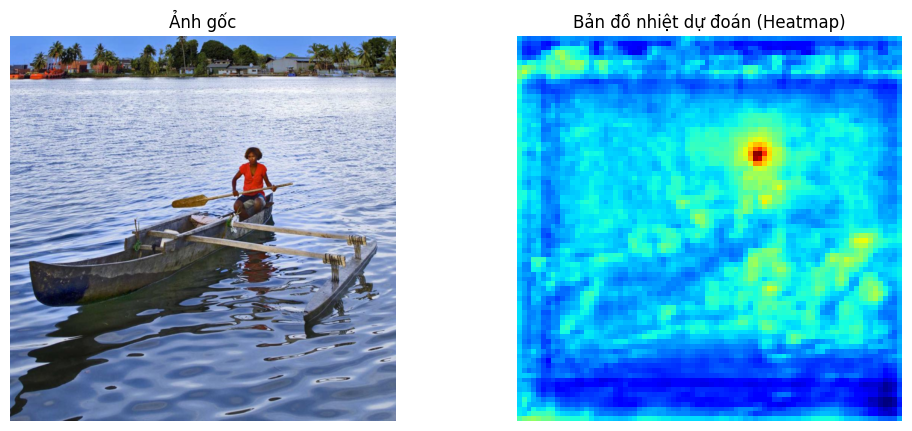

In [23]:
import matplotlib.pyplot as plt
import random

# 1. Thiết lập cấu hình cho Thủ khoa (Arch 14)

best_config = [df_leaderboard[idx][0] for idx in index]
set_active_architecture(supernet_backbone, best_config, SEARCH_SPACE)
supernet_backbone.eval()

# 2. Lấy 1 ảnh từ tập Validation để test
idx = random.randint(0, len(val_dataset)-1)
test_img, _ = val_dataset[idx]

# 3. Chạy Inference
with torch.no_grad():
    # Đưa về Float32 nếu trước đó bạn dùng Half
    input_tensor = test_img.unsqueeze(0).to(device).float()
    supernet_backbone.float()
    neck.float()
    head.float()
    
    out_heatmaps = head(neck(supernet_backbone(input_tensor)))

# 4. Vẽ kết quả
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_img.permute(1, 2, 0))
plt.title("Ảnh gốc")
plt.axis('off')

plt.subplot(1, 2, 2)
# Lấy Heatmap ở Scale 1 (Stride 4) - nơi chi tiết nhất
heatmap = out_heatmaps[0][0, 0].cpu().numpy()
plt.imshow(heatmap, cmap='jet')
plt.title("Bản đồ nhiệt dự đoán (Heatmap)")
plt.axis('off')
plt.show()

# The search results

## The paper's results
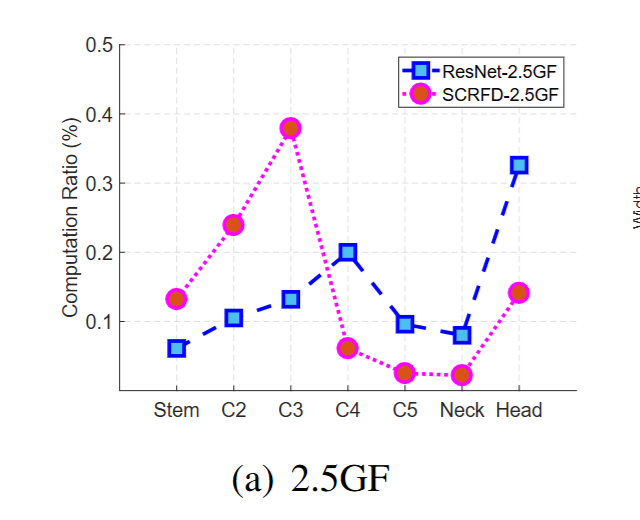

## Our results

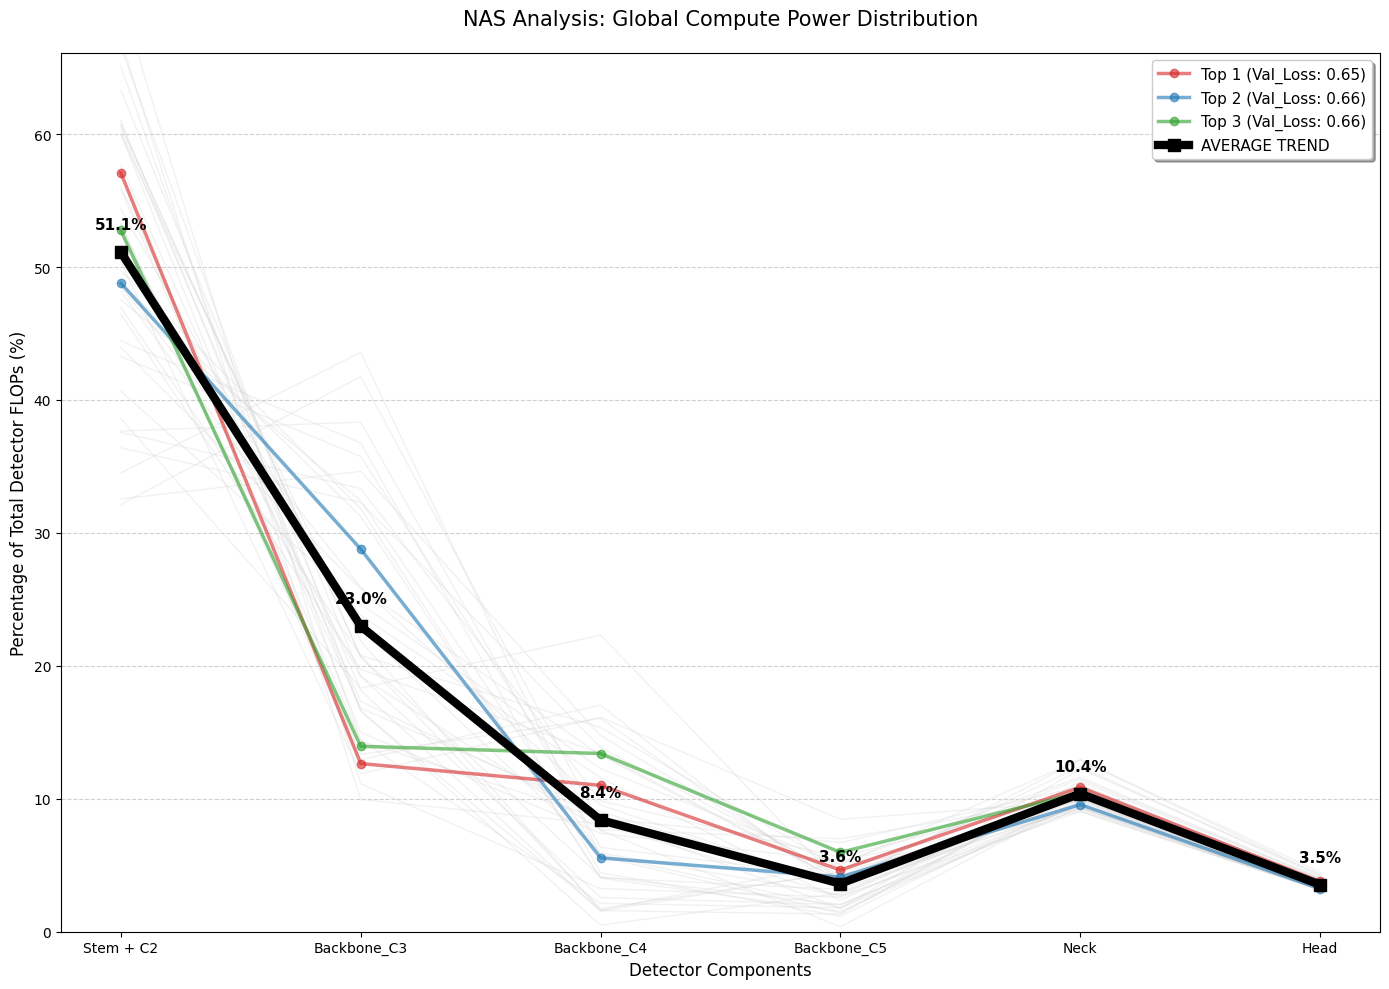

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Hàm tính toán % dựa vào LUT (Vẫn dùng hàm 3 thành phần)
def calculate_percentages_from_lut(c_widths, c_depths, lut):
    """
    c_widths: list [w2, w3, w4, w5]
    c_depths: list [d2, d3, d4, d5]
    lut: Dictionary my_lut
    """
    # Đầu vào của các tầng Backbone (Stem luôn xuất ra 16 kênh)
    in_widths = [16, c_widths[0], c_widths[1], c_widths[2]]
    
    # Lấy FLOPs thực tế của Backbone (Dùng Key 3 thành phần)
    c2 = lut['Backbone']['C2'][(in_widths[0], c_widths[0], c_depths[0])]
    c3 = lut['Backbone']['C3'][(in_widths[1], c_widths[1], c_depths[1])]
    c4 = lut['Backbone']['C4'][(in_widths[2], c_widths[2], c_depths[2])]
    c5 = lut['Backbone']['C5'][(in_widths[3], c_widths[3], c_depths[3])]
    
    stem = lut['Stem']
    
    # Lấy FLOPs của Neck Lateral
    stages = ['C2', 'C3', 'C4', 'C5']
    neck_lateral = sum([lut['Neck_Lateral'][stages[i]][c_widths[i]] for i in range(4)])
    
    # Lấy Fixed Cost và tách tỷ lệ
    fixed_cost = lut['Fixed_Cost']
    neck_fixed = fixed_cost * 0.7 
    head = fixed_cost * 0.3
    
    neck_total = neck_lateral + neck_fixed
    
    # Gom lại 6 phần
    costs = [c2 + stem, c3, c4, c5, neck_total, head]
    total_cost = sum(costs)
    
    # Quy ra tỷ lệ %
    percentages = [c / total_cost * 100 for c in costs]
    return percentages

# ==========================================
# 2. Xử lý DataFrame (RẤT GỌN GÀNG)
# ==========================================
# Lấy thẳng df_leaderboard của bạn
df = df_leaderboard.nsmallest(40, 'Val_Loss').copy() 
cols = ['C2_percent', 'C3_percent', 'C4_percent', 'C5_percent', 'Neck_percent', 'Head_percent']

# Gọi thẳng các cột có sẵn: 'C2_w', 'C2_d'... mà không cần extract
df[cols] = df.apply(lambda r: pd.Series(calculate_percentages_from_lut(
    [int(r['C2_w']), int(r['C3_w']), int(r['C4_w']), int(r['C5_w'])], 
    [int(r['C2_d']), int(r['C3_d']), int(r['C4_d']), int(r['C5_d'])],
    my_lut 
)), axis=1)

# ==========================================
# 3. Vẽ đồ thị trực quan
# ==========================================
plt.figure(figsize=(14, 10), dpi=100)
x_stages = ['Stem + C2', 'Backbone_C3', 'Backbone_C4', 'Backbone_C5', 'Neck', 'Head']

# Vẽ nền mờ (Background) cho các mạng từ Top 4 trở đi
for i in range(3, len(df)):
    plt.plot(x_stages, df.iloc[i][cols], color='lightgray', alpha=0.3, linewidth=1)

# Vẽ Top 3
colors = ['#d62728', '#1f77b4', '#2ca02c']
for i in range(min(3, len(df))): 
    plt.plot(x_stages, df.iloc[i][cols], color=colors[i], alpha=0.6, linewidth=2.5, 
             marker='o', label=f"Top {i+1} (Val_Loss: {df.iloc[i]['Val_Loss']:.2f})")

# Vẽ đường trung bình
mean_vals = df[cols].mean()
plt.plot(x_stages, mean_vals, color='black', linewidth=6, marker='s', markersize=9, 
         zorder=10, label='AVERAGE TREND')

# Ghi chú giá trị %
for i, val in enumerate(mean_vals):
    plt.text(i, val + 1.5, f'{val:.1f}%', ha='center', va='bottom', 
             fontweight='bold', color='black', fontsize=11)

plt.title('NAS Analysis: Global Compute Power Distribution', fontsize=15, pad=20)
plt.ylabel('Percentage of Total Detector FLOPs (%)', fontsize=12)
plt.xlabel('Detector Components', fontsize=12)
plt.ylim(0, max(mean_vals) + 15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(frameon=True, shadow=True, fontsize=11)
plt.tight_layout()
plt.show()